In [15]:
import numpy as np
import matplotlib.pyplot as pl

In [16]:
Factor = 10

In [17]:
Width  = 64 * Factor
Height = 48 * Factor

In [18]:
def Clear ():
    global Img
    Img = np.zeros ((Height, Width))

In [19]:
def Show (img):
    pl.imshow (img, cmap = 'gray')
    pl.axis ('equal')
    pl.axis ('off')

In [20]:
def Pixel (x, y):
    return Img [Height - 1 - y, x]

In [21]:
def SetPixel (x, y):
    global Img
    Img [Height - 1 - y, x] = 1

In [22]:
def Line (x0, y0, x1, y1):
    dx = x1 - x0
    dy = y1 - y0
    d = max (abs (dx), abs (dy))
    mx = dx / d
    my = dy / d
    for i in range (d + 1):
        x = int (x0 + mx * i + 0.5)
        y = int (y0 + my * i + 0.5)
        SetPixel (x, y)
    m = dy / dx
    t = y0 - m * x0
    print (np.round ([m, t], 2)) 

[ 0.73 13.64]
[ -1.25 425.  ]
[9.0000e-02 1.9545e+02]


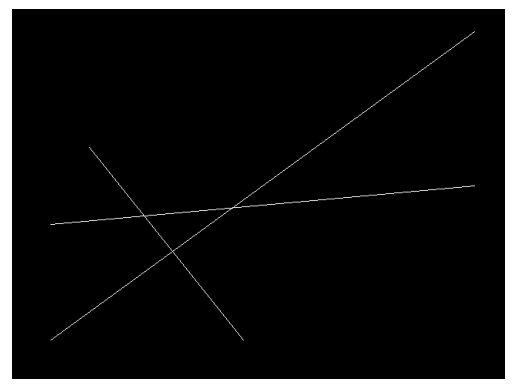

In [23]:
Clear()
Line ( 5 * Factor,  5 * Factor, 60 * Factor, 45 * Factor)
Line (10 * Factor, 30 * Factor, 30 * Factor,  5 * Factor)
Line ( 5 * Factor, 20 * Factor, 60 * Factor, 25 * Factor)
Show (Img)

In [24]:
Mmin = -10
Mmax = 10
Mnum = 100

Tmin = -100 * Factor
Tmax = 100 * Factor
Tnum = 100

MM = np.linspace (Mmin, Mmax, Mnum)
TT = np.linspace (Tmin, Tmax, Tnum)
Tdelta = (Tmax - Tmin) / Tnum

Akku = np.zeros ((Mnum, Tnum))

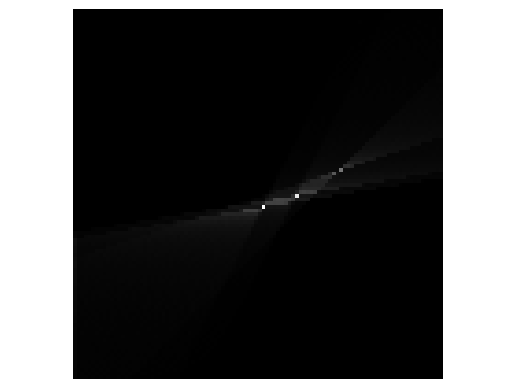

In [25]:
for x0 in range (Width):
    for y0 in range (Height):
        if Pixel (x0, y0) != 0:
            for u, m in enumerate (MM):
                # y = m * (x - x0) + y0 = m * x - m * x0 + y0
                t = y0 - m * x0
                v = int ((t - Tmin) / Tdelta + 0.5)
                if v >= 0 and v < Tnum:
                    Akku [u, v] += 1
                    
Show (Akku)

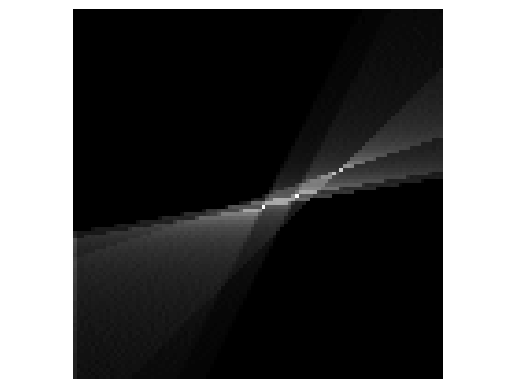

In [26]:
tmp = np.copy(Akku)
for i in range(5):
  tmp = np.log(1 + tmp / np.max(tmp))
Show(tmp)

In [27]:
count = 3

tmp = np.copy (Akku)
for i in range (count):
    [j, k] = np.where (tmp == tmp.max())
    j = j [0]
    k = k [0]
    print (MM [j], TT [k])
    tmp [j, k] = 0


0.7070707070707076 30.303030303030255
0.10101010101010033 212.121212121212
-1.3131313131313131 454.5454545454545
